In [34]:
import numpy as np
import pickle
import json
import os
from pathlib import Path

DATA_DIR = Path("/global/cfs/cdirs/m3246/gregork")
CKPT_DIR = Path("/global/cfs/cdirs/m3246/gregork/checkpoints")

playlists = ["1A", "1B", "1E", "1M", "1P", "1D", "1L", "1G", "1O", "1C", "1F", "1A", "1N"]
playlists = ["1A"]

# To evaluate:
# - energy regression: CONT_max_blob_and_prong_log_1A_20260205_031125, CONT_max_blob_and_prong_log_PretrainedSmall_1A_20260205_031322
# - CC (current classification): cont_classification_current_type_1A_20260204_013605, CONT_classification_current_type_Pretrained_1A_20260203_202002
# - EC (event classification): cont_classification_event_type_1A_20260204_013827, CONT_classification_event_type_Pretrained_1A_20260203_201240


training_names = {
  "cc": {
    "1A": "cont_classification_current_type_1A_20260204_013605",
    "Pretrained_1A": "CONT_classification_current_type_Pretrained_1A_20260203_202002",
    "1A_TransformerSmall": "Train_CC_SmallModel_20260210_004255",
    "1A_Transformer": "Train_CC_20260210_003828"
  },
  "ec": {
    "1A": "cont_classification_event_type_1A_20260204_013827",
    "Pretrained_1A": "CONT_classification_event_type_Pretrained_1A_20260203_201240"
  },
  "er": {
    "1A": "CONT_max_blob_and_prong_log_1A_20260205_031125",
    "Pretrained_1A": "CONT_max_blob_and_prong_log_PretrainedSmall_1A_20260205_031322",
      "1A_TransformerSmall": "Train_Regression_SmallModel_20260210_003728",
      "1A_Transformer": "Train_Regression_20260210_003302"
  }
}



In [35]:
results = {}
configs = {}
for key in training_names.keys():
    results[key] = {}
    configs[key] = {}
    for model in training_names[key]:
        # File looks like this: CKPT_DIR/training_name/outputs_cont_classification_current_type_<PLAYLIST>_20260204_013605_minerva_<PLAYLIST>_0.npz
        results[key][model] = {}
        configs[key][model] = {}
        for playlist in playlists:
            path1 = CKPT_DIR / training_names[key][model] / "test_results" / f"outputs_{training_names[key][model]}_minerva_{playlist}_0.npz"
            path2 = CKPT_DIR / training_names[key][model] / "test_results" / f"outputs_best_model_minerva_{playlist}_0.npz"
            if path1.exists():
                results[key][model][playlist] = np.load(path1)
            elif path2.exists():
                results[key][model][playlist] = np.load(path2)
            else:
                raise ValueError(f"No results found for {training_names[key][model]} on playlist {playlist} - {path1} and {path2} do not exist")
            settings_path = CKPT_DIR / training_names[key][model] / "settings.json"
            if settings_path.exists():
                configs[key][model][playlist] = json.load(open(settings_path, "rb"))
            else:
                print(f"No settings found for {training_names[key][model]} on playlist {playlist}")
                configs[key][model][playlist] = {}


No settings found for Train_CC_SmallModel_20260210_004255 on playlist 1A
No settings found for Train_CC_20260210_003828 on playlist 1A
No settings found for Train_Regression_SmallModel_20260210_003728 on playlist 1A
No settings found for Train_Regression_20260210_003302 on playlist 1A


In [36]:
t = results["er"]["1A"]["1A"]
y_pred = np.exp(t["prediction"]).flatten()
y_true = t["pid"].flatten()

In [22]:
np.mean(((np.log(y_true)-np.log(y_pred))**2))

np.float32(0.082144246)

### Energy regression

In [23]:
E_true_dict, E_pred_dict = {}, {}  # Eval. dataset -> model -> E_true, E_pred, E_pred_over_true mapping
E_pred_over_true_dict = {}

regression_task = "er"

for model in results[regression_task].keys():
    for eval_dataset in results[regression_task][model].keys():
        E_true = results[regression_task][model][eval_dataset]["pid"]
        E_pred = np.exp(results[regression_task][model][eval_dataset]["prediction"].flatten())
        E_pred_over_true = E_pred / E_true
        if eval_dataset not in E_true_dict:
            E_true_dict[eval_dataset] = {}
            E_pred_dict[eval_dataset] = {}
            E_pred_over_true_dict[eval_dataset] = {}
        E_true_dict[eval_dataset][model] = E_true
        E_pred_dict[eval_dataset][model] = E_pred
        E_pred_over_true_dict[eval_dataset][model] = E_pred_over_true



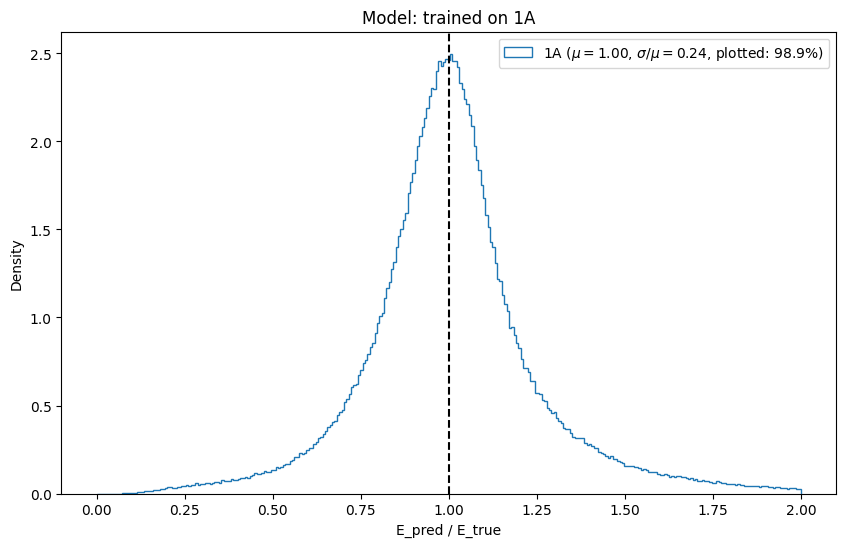

In [24]:
import matplotlib.pyplot as plt
bins = np.linspace(0, 2, 300)
fig, ax = plt.subplots(figsize=(10, 6))
model_name = "1A"  # Select model "1A"
for eval_dataset in E_pred_over_true_dict.keys():
    if model_name in E_pred_over_true_dict[eval_dataset]:
        data = E_pred_over_true_dict[eval_dataset][model_name]
        # also compute and print RMS
        #print(f"{eval_dataset} (model {model_name}) RMS/median: {rms/mpv_data}")
        # fraction of events where e_reco / e_true is in [0, 2]
        mask = (data >= 0) & (data <= 2)
        frac_in_range = np.sum(mask) / len(data) * 100
        data = data[mask]
        mpv_data = np.median(data)
        rms = np.sqrt(np.mean((data - mpv_data)**2))
        ax.hist(data, bins=bins, density=True, histtype="step", label=eval_dataset + fr" ($\mu={mpv_data:.2f}$, $\sigma/\mu={rms/mpv_data:.2f}$, plotted: {frac_in_range:.1f}%)")
        # Also print the median and RMS/Median for each dataset on the plot
        #print(f"{eval_dataset} (model {model_name}) median: {mpv_data}")
        #print(f"{eval_dataset} (model {model_name}) RMS/median: {rms/mpv_data}")
#ax.set_yscale("log")
ax.axvline(1, color="black", linestyle="--")
ax.set_xlabel("E_pred / E_true")
ax.set_ylabel("Density")
ax.legend()
ax.set_title("Model: trained on 1A")
fig.show()



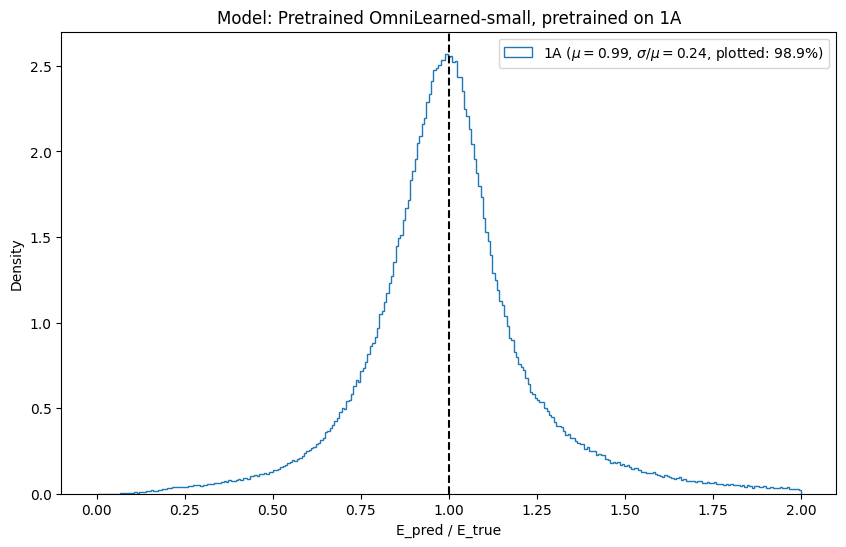

In [13]:
import matplotlib.pyplot as plt
bins = np.linspace(0, 2, 300)
fig, ax = plt.subplots(figsize=(10, 6))
model_name = "Pretrained_1A"  # Select model "1A"
for eval_dataset in E_pred_over_true_dict.keys():
    if model_name in E_pred_over_true_dict[eval_dataset]:
        data = E_pred_over_true_dict[eval_dataset][model_name]
        # also compute and print RMS
        mask = (data >= 0) & (data <= 2)
        frac_in_range = np.sum(mask) / len(data) * 100
        data = data[mask]
        mpv_data = np.median(data)
        rms = np.sqrt(np.mean((data - mpv_data)**2))
        #print(f"{eval_dataset} (model {model_name}) RMS/median: {rms/mpv_data}")
        ax.hist(data, bins=bins, density=True, histtype="step", label=eval_dataset + fr" ($\mu={mpv_data:.2f}$, $\sigma/\mu={rms/mpv_data:.2f}$, plotted: {frac_in_range:.1f}%)")
        # Also print the median and RMS/Median for each dataset on the plot
        #print(f"{eval_dataset} (model {model_name}) median: {mpv_data}")
        #print(f"{eval_dataset} (model {model_name}) RMS/median: {rms/mpv_data}")
        
ax.axvline(1, color="black", linestyle="--")
ax.set_xlabel("E_pred / E_true")
ax.set_ylabel("Density")
ax.legend()
ax.set_title("Model: Pretrained OmniLearned-small, pretrained on 1A")
fig.show()





In [14]:


def get_Enu_fig(mc_E, reco_e_dict: dict):
    # reco_e_dict: key should be what's plotted. value should be same shape as mc_E, if it's not reconstructed, it should have value -1.
    # fig should have 2 x 2 subplots. left: counts; right: normalized histograms to unit area.
    # Top: E / 1000 histograms (GeV); Bottom: E_reco/E_mc
    import numpy as np
    import matplotlib.pyplot as plt
    # make the font of legend a bit smaller

    
    fig, ax = plt.subplots(2, 2, figsize=(12, 12))
    bins_E = np.linspace(0, 50, 300)
    bins_E_reco_over_true = np.linspace(0, 2, 100)
    ax[0, 0].hist(mc_E, bins=bins_E, histtype='step', color='black', label='MC E')
    ax[0, 1].hist(mc_E, bins=bins_E, histtype='step', color='black', label='MC E', density=True)
    
    # Store statistics for text boxes
    stats_text_10 = []  # for ax[1,0]
    stats_text_11 = []  # for ax[1,1]
    
    for method in reco_e_dict.keys():
        mask = reco_e_dict[method] > 0
        percentage_reconstructed = round(np.sum(mask) / len(mask) * 100, 1)
        ax[0, 0].hist(reco_e_dict[method], bins=bins_E, histtype='step', label=method + f" ({percentage_reconstructed}%)")
        ax[0, 1].hist(reco_e_dict[method], bins=bins_E, histtype='step', label=method + f" ({percentage_reconstructed}%)", density=True)
        E_reco_over_true = reco_e_dict[method][mask] / mc_E[mask]
        # MPV (Most Probable Value) - use the bin with max count
        counts, bin_edges = np.histogram(E_reco_over_true, bins=bins_E_reco_over_true)
        mpv_idx = np.argmax(counts)
        mpv = (bin_edges[mpv_idx] + bin_edges[mpv_idx + 1]) / 2
        # Calculate RMS from MPV
        # rms = np.sqrt(np.mean((E_reco_over_true - mpv)**2)) # compute rms from the values bounded by [0, 2]
        mask = (E_reco_over_true >= 0) & (E_reco_over_true <= 2)
        rms = np.sqrt(np.mean((E_reco_over_true[mask] - mpv)**2))
        ax[1, 0].hist(E_reco_over_true, bins=bins_E_reco_over_true, histtype='step', label=method + f" ({percentage_reconstructed}%)")
        ax[1, 1].hist(E_reco_over_true, bins=bins_E_reco_over_true, histtype='step', label=method + f" ({percentage_reconstructed}%)", density=True)
        # Add statistics to text lists
        stats_text_10.append(f"{method}: RMS={rms:.3f}, MPV={mpv:.3f}")
        stats_text_11.append(f"{method}: RMS={rms:.3f}, MPV={mpv:.3f}")
    fontsize_legend = 6.5
    ax[0, 0].legend(fontsize=fontsize_legend)
    ax[0, 0].set_xlabel("Energy [GeV]")
    ax[0, 0].set_ylabel("Counts")
    ax[0, 0].set_title("E nu Distribution")
    ax[0, 1].legend(fontsize=fontsize_legend)
    ax[0, 1].set_xlabel("Energy [GeV]")
    ax[0, 1].set_ylabel("Relative counts")
    ax[0, 1].set_title("E nu Distribution (normalized)")
    ax[1, 0].legend(fontsize=fontsize_legend)
    ax[1, 0].set_xlabel("E reco / E true")
    ax[1, 0].set_ylabel("Counts")
    ax[1, 0].set_title("E reco / E true Distribution")
    ax[1, 1].legend(fontsize=fontsize_legend)
    ax[1, 1].set_xlabel("E reco / E true")
    ax[1, 1].set_ylabel("Relative counts")
    ax[1, 1].set_title("E reco / E true Distribution (normalized)")
    
    # Add statistics text boxes to bottom plots
    stats_text_str_10 = '\n'.join(stats_text_10)
    stats_text_str_11 = '\n'.join(stats_text_11)
    
    ax[1, 0].text(0.98, 0.97, stats_text_str_10, transform=ax[1, 0].transAxes,
                  fontsize=8, verticalalignment='top', horizontalalignment='right',
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax[1, 1].text(0.98, 0.97, stats_text_str_11, transform=ax[1, 1].transAxes,
                  fontsize=8, verticalalignment='top', horizontalalignment='right',
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Put a grid on all
    ax[0, 0].grid(True)
    ax[0, 1].grid(True)
    ax[1, 0].grid(True)
    ax[1, 1].grid(True)

    # put legends on upper left for bottom plots to avoid overlap with stats
    ax[0, 0].legend(loc='lower right', fontsize=fontsize_legend)
    ax[0, 1].legend(loc='lower right', fontsize=fontsize_legend)
    ax[1, 0].legend(loc='upper left', fontsize=fontsize_legend)
    ax[1, 1].legend(loc='upper left', fontsize=fontsize_legend)
    fig.tight_layout()
    return fig


In [15]:
Enu_baselines = {} # Eval. dataset -> model -> Enu_baselines
mc_E = {}

model = "1A"
for eval_dataset in configs[regression_task][model]:
    if eval_dataset not in Enu_baselines:
        Enu_baselines[eval_dataset] = {}
    settings = configs[regression_task][model][eval_dataset]
    split_idx = os.path.join(settings["path"], "result.pkl")
    split_idx = pickle.load(open(split_idx, "rb"))
    current_baselines = os.path.join(settings["path"], "baselines", f"{eval_dataset}_enu_baselines.npz")
    current_baselines = np.load(current_baselines, mmap_mode="r")
    mc_E[eval_dataset] = current_baselines["E_true"][split_idx[eval_dataset]["test_idx"]] / 1000
    for key in current_baselines.keys():
        if key not in ["E_true", "E_muon"]:
            Enu_baselines[eval_dataset][key] = current_baselines[key][split_idx[eval_dataset]["test_idx"]] / 1000


In [16]:
mc_E.keys()

dict_keys(['1A'])

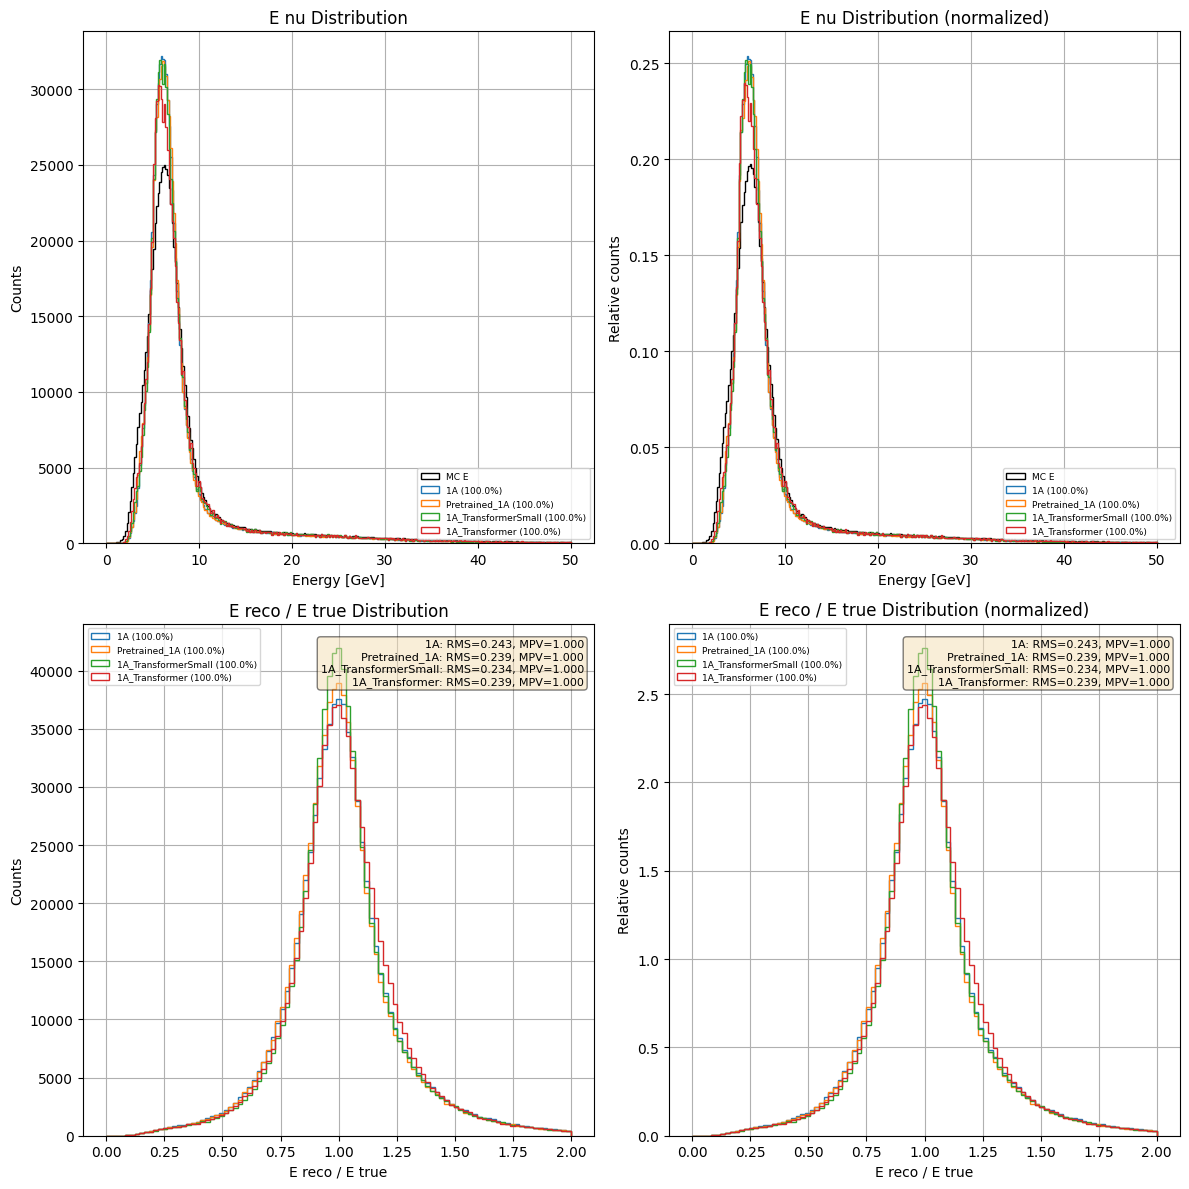

In [18]:
models_to_plot = ["1A", "Pretrained_1A", "1A_TransformerSmall", "1A_Transformer"]
dataset_to_plot = "1A"

dict_model_E_reco = {key: E_pred_dict[dataset_to_plot][key] for key in models_to_plot}
dict_baselines_E_reco = Enu_baselines[dataset_to_plot]
get_Enu_fig(mc_E[dataset_to_plot], dict_model_E_reco).show()

In [ ]:
def get_baseline_and_models_E_filtered(E_true, baseline_E_reco, baseline_name, model_E_reco_dict):
    mask = baseline_E_reco >= 0
    baseline_E_reco = baseline_E_reco[mask]
    E_true = E_true[mask]
    output_dict = {}
    output_dict[baseline_name] = baseline_E_reco
    for model_name in model_E_reco_dict.keys():
        output_dict[model_name] = model_E_reco_dict[model_name][mask]
    return E_true, output_dict


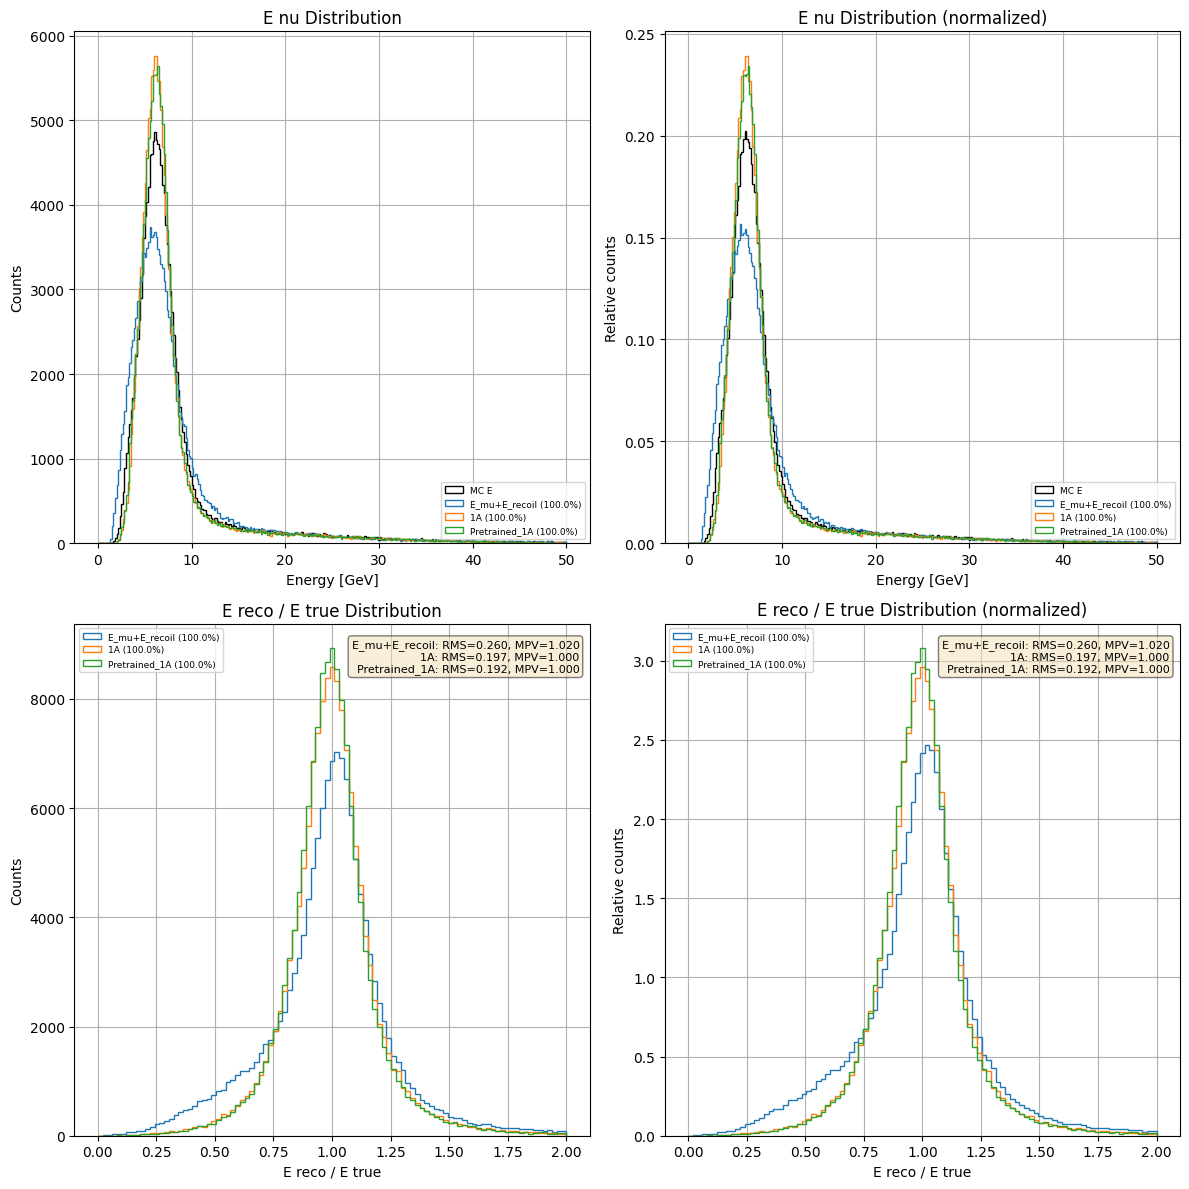

In [ ]:
mc_E_filtered, methods_filtered = get_baseline_and_models_E_filtered(mc_E[dataset_to_plot], dict_baselines_E_reco["E_mu+E_recoil"], "E_mu+E_recoil", dict_model_E_reco)
get_Enu_fig(mc_E_filtered, methods_filtered).show()

### Classification tasks: binary (event current: CC or NC); multiclass (event type)

In [26]:
model_to_plot = "1A"
datasets = results["ec"][model_to_plot].keys()
labels_current_type = ["CC", "NC"]
labels_event_type = ["CCQE", "RES", "DIS", "Coherent", "2p2h"]
len(datasets)

1

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix_on_ax(ax, y_true, y_pred, class_names):
    # Compute the confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    #ax.set_title("Confusion Matrix")
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)


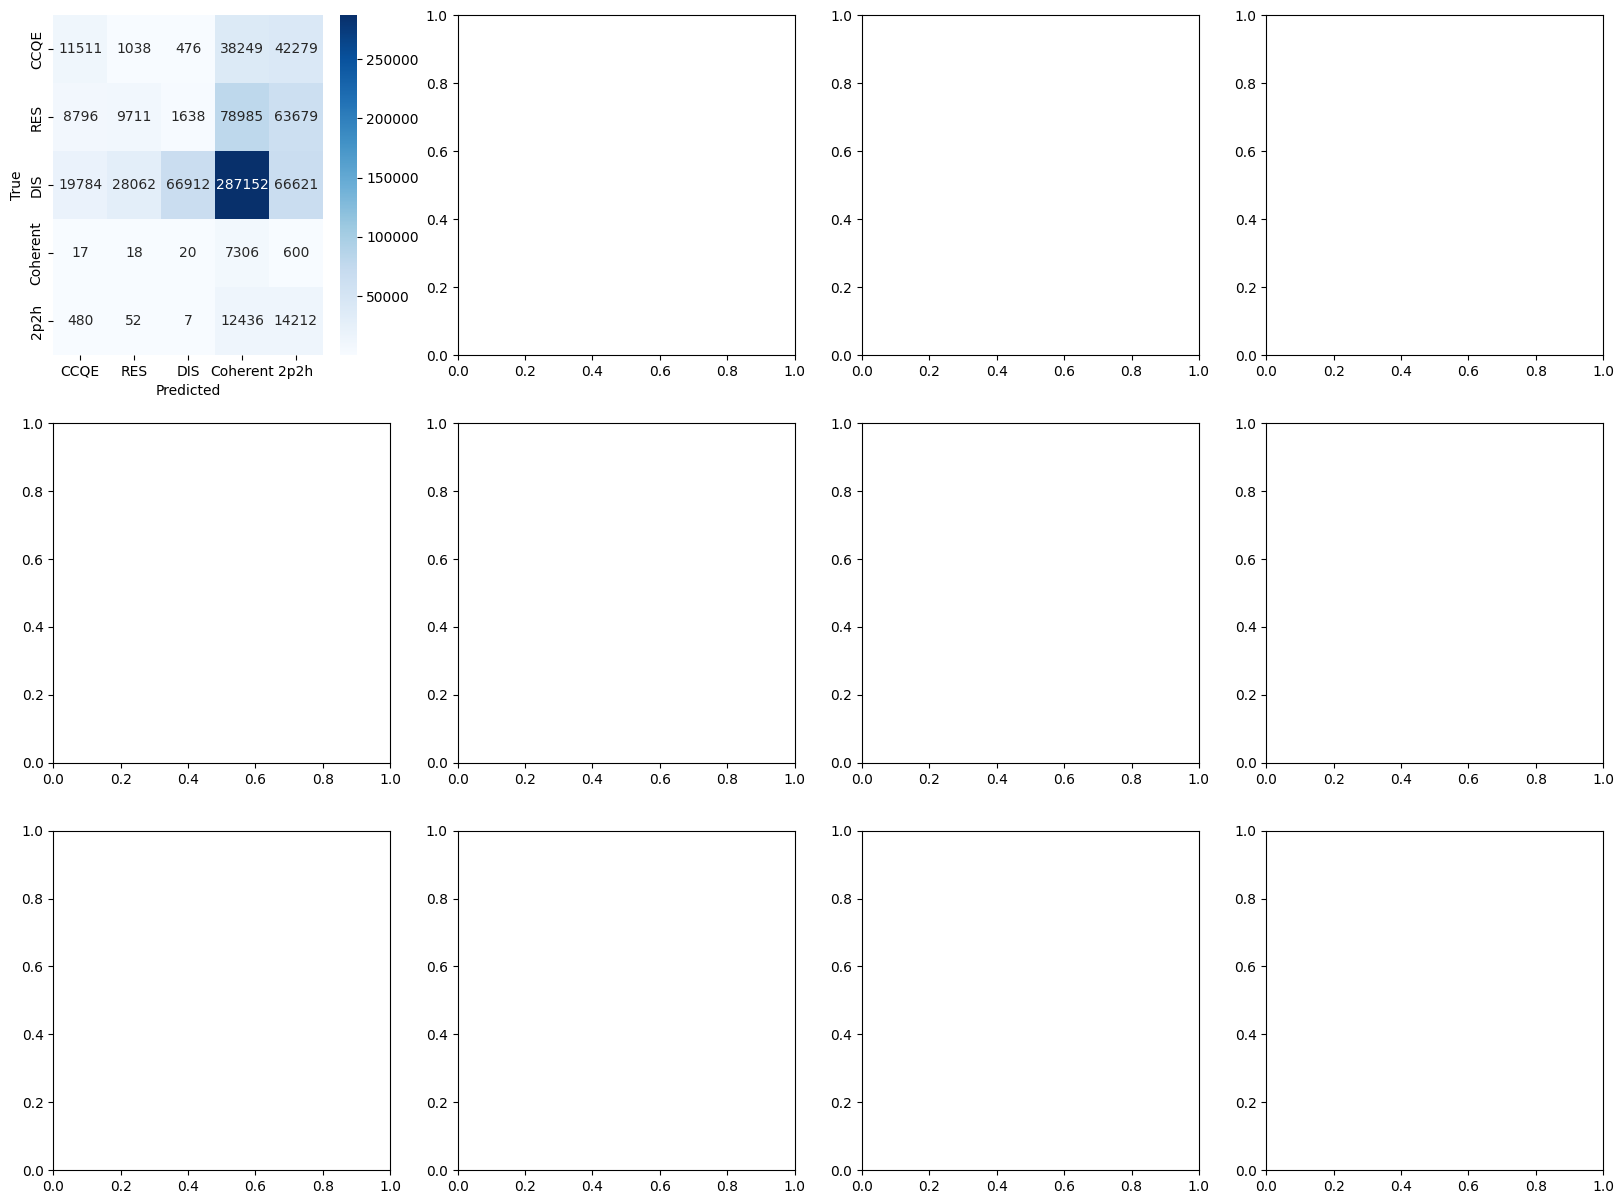

In [28]:
# 12 datasets: Make a 3x4 grid of confusion matrices
fig, ax = plt.subplots(3, 4, figsize=(20, 15))
for i, dataset in enumerate(datasets):
    plot_confusion_matrix_on_ax(ax[i // 4, i % 4], results["ec"][model_to_plot][dataset]["pid"], results["ec"][model_to_plot][dataset]["prediction"].argmax(axis=1), labels_event_type)
fig.show()


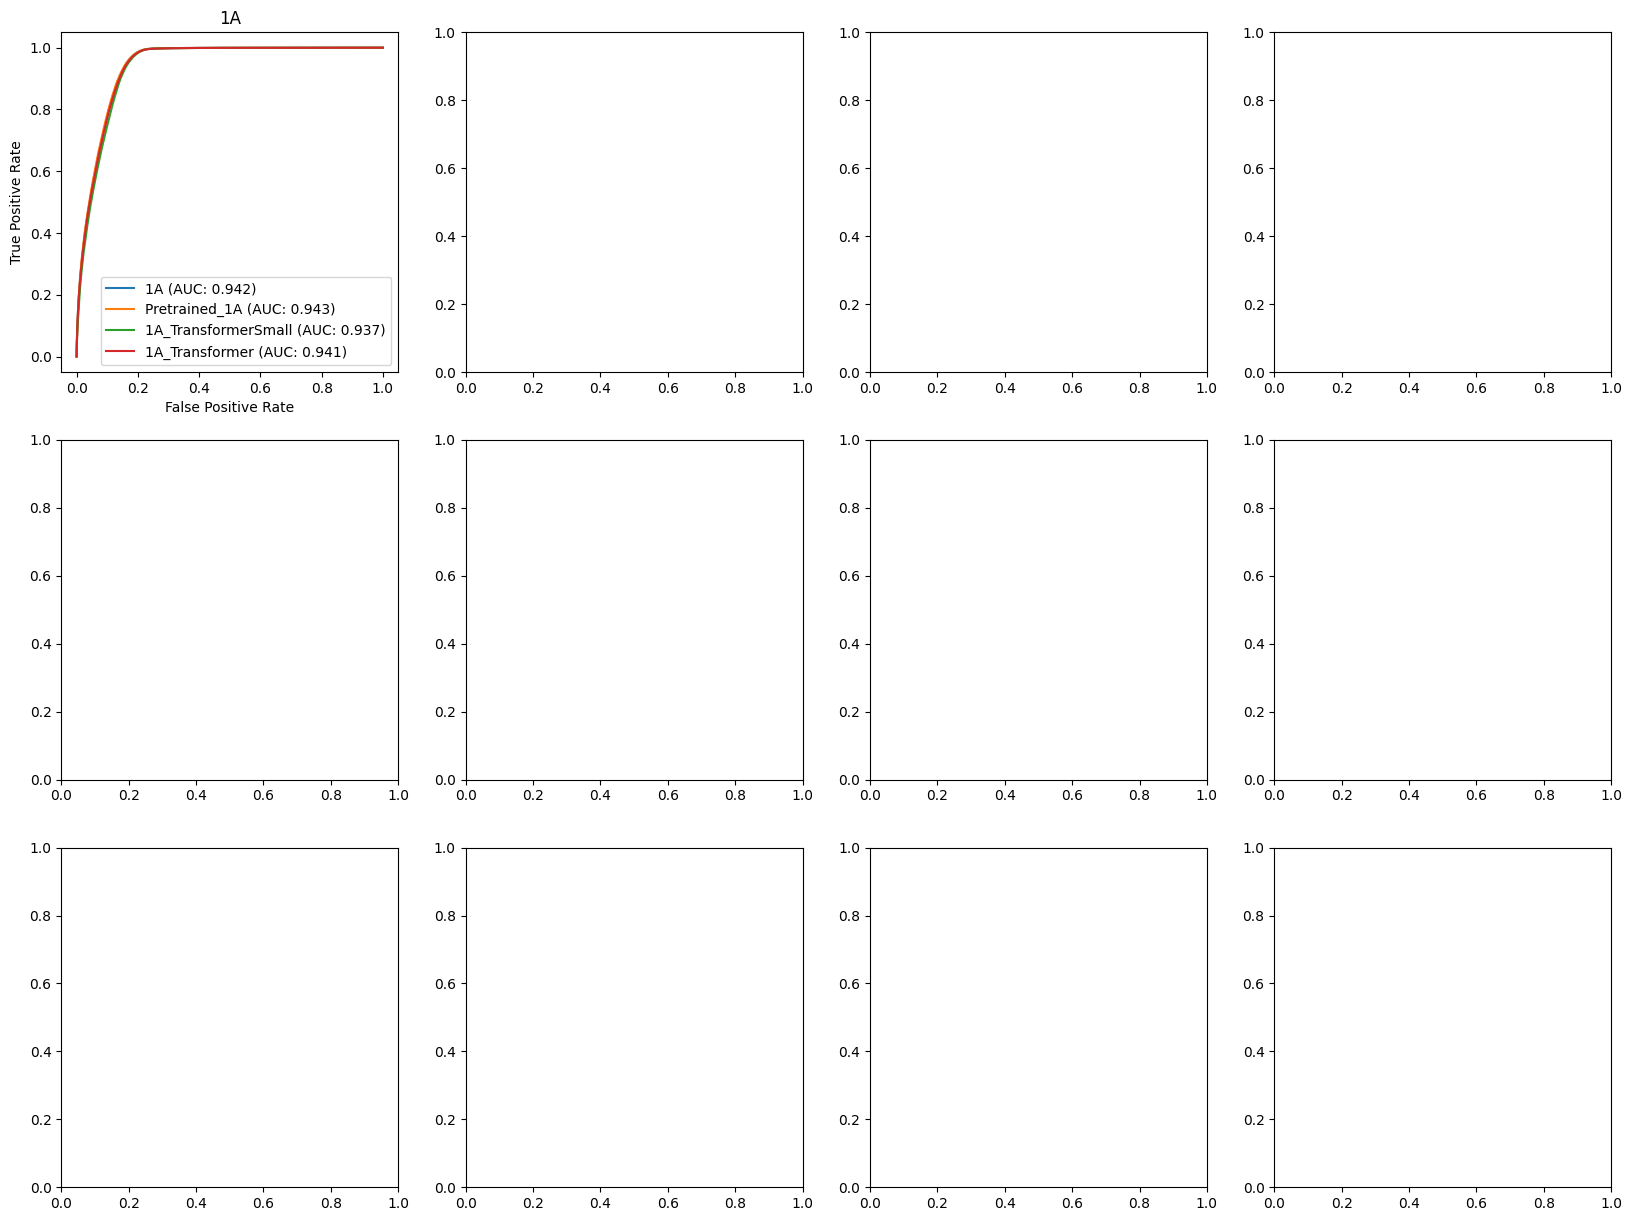

In [37]:
# now make a similar plot but of roc curves for binary classification (CC/NC)
from sklearn.metrics import roc_curve, auc

def plot_roc_curve_on_ax(ax, y_true, y_pred, class_names, label=None):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    auc_score = auc(fpr, tpr)
    if label:
        label = label + f" (AUC: {auc_score:.3f})"
    ax.plot(fpr, tpr, label=label)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    # also compute AUC and print it in a text box
    #ax.text(0.05, 0.95, f"AUC: {auc_score:.2f}", transform=ax.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left')
    #ax.legend()

# 12 datasets: Make a 3x4 grid of ROC curves
fig, ax = plt.subplots(3, 4, figsize=(20, 15))
for model_to_plot in ["1A", "Pretrained_1A", "1A_TransformerSmall", "1A_Transformer"]:
    for i, dataset in enumerate(datasets):
        plot_roc_curve_on_ax(ax[i // 4, i % 4], results["cc"][model_to_plot][dataset]["pid"], results["cc"][model_to_plot][dataset]["prediction"][:, 1], labels_current_type, label=model_to_plot)
        # also plot the AUC metric on the top left of the plot
        # Turn on legend
        # NC is the positive class
        
for i, dataset in enumerate(datasets):
    ax[i // 4, i % 4].legend()
    ax[i // 4, i % 4].set_title(dataset)
    # Try doing log x and y scales
    #ax[i // 4, i % 4].set_xscale("log")
    #ax[i // 4, i % 4].set_yscale("log")
fig.show()


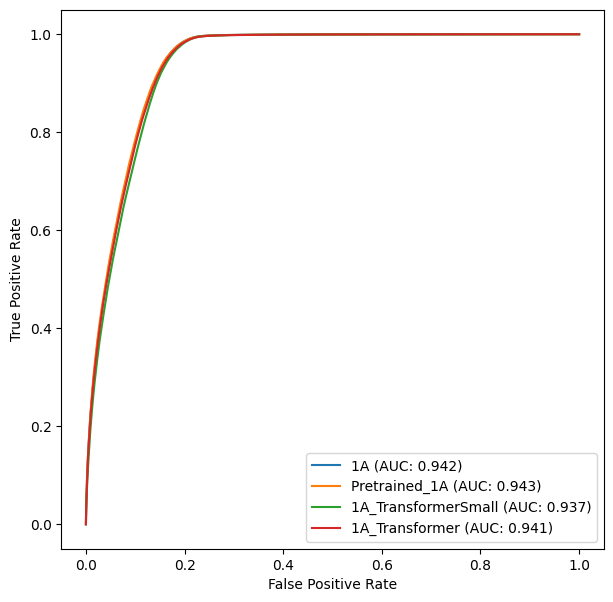

In [41]:
# just plot the 1A roc curve for different models
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
for model_to_plot in ["1A", "Pretrained_1A", "1A_TransformerSmall", "1A_Transformer"]:
    plot_roc_curve_on_ax(ax, results["cc"][model_to_plot]["1A"]["pid"], results["cc"][model_to_plot]["1A"]["prediction"][:, 1], labels_current_type, label=model_to_plot)
ax.legend()
fig.show()


In [ ]:
# print the percentage of NC ground truth events in each dataset
for dataset in datasets:
    print(f"{dataset}: {np.sum(results['cc'][model_to_plot][dataset]['pid'] == 1) / len(results['cc'][model_to_plot][dataset]['pid'])}")


1A: 0.09783024863132384
1B: 0.09833963184200901
1E: 0.0926674247240834
1M: 0.09599627429465263
1P: 0.09485284243356053
1D: 0.09817456543562107
1L: 0.09654383110741176
1G: 0.0980247487683286
1O: 0.0946292669177008
1C: 0.09785349181169582
1F: 0.09780222420087396
1N: 0.09549575586311722


In [33]:
results["cc"][model_to_plot][dataset]["prediction"]

array([1, 1, 0, ..., 0, 0, 0], shape=(760041,))